# **Análise Exploratória de Dados (EDA) - Detecção de Fake News**

Este notebook tem como objetivo explorar o dataset de treino fornecido para o desafio de classificação de fake news. Vamos analisar a distribuição das classes, verificar a presença de duplicatas, identificar possíveis vieses e entender a estrutura dos dados.


As etapas realizadas incluem:

- Carregamento e inspeção inicial
- Verificação de valores ausentes
- Distribuição das classes
- Análise de duplicatas e detecção de vazamento de dados
- Estatísticas de comprimento de texto e título
- Identificação de vieses (ex: palavra "Reuters")
- Análise de palavras mais frequentes por classe
- Exploração de variáveis adicionais

In [1]:
# Instalações e Imports
!pip install -q matplotlib seaborn pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Carregamos os arquivos train.csv e test.csv para compreender sua estrutura geral.
Verificamos as dimensões, os tipos das colunas e as primeiras observações.


In [2]:
# Carregamento dos dados
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("=== Dados de Treino ===")
print("Shape:", train.shape)
print("\nPrimeiras linhas:")
train.head()

print("\n=== Dados de Teste ===")
print("Shape:", test.shape)
print("\nPrimeiras linhas:")
test.head()

=== Dados de Treino ===
Shape: (22844, 6)

Primeiras linhas:

=== Dados de Teste ===
Shape: (5712, 5)

Primeiras linhas:


,id,title,text,subject,date
0,5398,Obama’s “CLOCK BOY” Comes Back To Texas…After ...,After 9 Months Of Hard-Core Islam Muslim Cloc...,politics,"Jun 27, 2016"
1,5503,LGBT VOLUNTEERS Aren’t Waiting To Be Thrown Of...,A group of volunteer soldiers announced this w...,politics,"Jul 25, 2017"
2,23151,Colombia authorizes air raids against dissiden...,BOGOTA (Reuters) - Colombia s armed forces hav...,worldnews,"October 31, 2017"
3,12669,"Timeline: Trump questions then honors ""one Chi...",(Reuters) - U.S. President Donald Trump agreed...,politicsNews,"February 10, 2017"
4,27864,Three policemen killed in Peru in drug-traffic...,LIMA (Reuters) - Three Peruvian policemen were...,worldnews,"September 7, 2017"


Analisamos os tipos das colunas e estatísticas descritivas básicas.
Isso ajuda a identificar colunas numéricas e categóricas, além de possíveis inconsistências.


In [3]:
# Informações gerais
print("\n=== Informações do dataset de treino ===")
train.info()

print("\n=== Estatísticas descritivas (colunas numéricas) ===")
print(train['label'].describe())


=== Informações do dataset de treino ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22844 entries, 0 to 22843
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       22844 non-null  int64 
 1   title    22844 non-null  object
 2   text     22844 non-null  object
 3   subject  22844 non-null  object
 4   date     22844 non-null  object
 5   label    22844 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.0+ MB

=== Estatísticas descritivas (colunas numéricas) ===
count    22844.000000
mean         0.250000
std          0.433022
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          1.000000
Name: label, dtype: float64


O dataset de treino possui 22.844 amostras e 6 colunas (id, title, text, subject, date, label).

Não há valores nulos em nenhuma coluna – isso facilita o pré-processamento.

A coluna label tem média 0,25, indicando que 25% das notícias são falsas (label 1) e 75% são verdadeiras (label 0). Portanto, a classe majoritária é a de notícias reais.

Desbalanceamento moderado, reforçando a adequação da métrica F1 Macro (dá peso igual às duas classes).

Os quartis mostram que 75% dos dados pertencem à classe 0 (real), consistente com a média.




=== Distribuição das classes ===
label
0    17133
1     5711
Name: count, dtype: int64

Proporção:
label
0    0.75
1    0.25
Name: proportion, dtype: float64


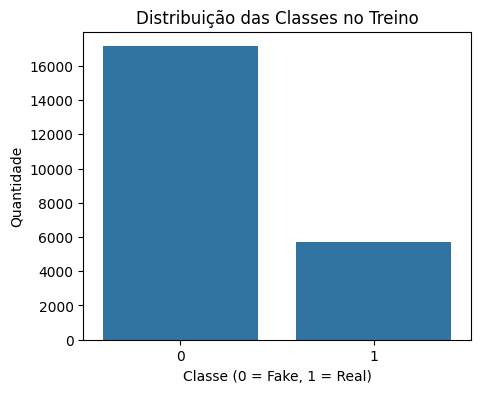

In [4]:
# 4. Distribuição das classes
print("\n=== Distribuição das classes ===")
class_dist = train['label'].value_counts()
print(class_dist)
print("\nProporção:")
print(train['label'].value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x='label', data=train)
plt.title('Distribuição das Classes no Treino')
plt.xlabel('Classe (0 = Fake, 1 = Real)')
plt.ylabel('Quantidade')
plt.show()

Os dados de treino apresentam a seguinte distribuição:

Classe 0 (fake): 17.133 amostras (75%)

Classe 1 (real): 5.711 amostras (25%)



In [8]:
# Análise de duplicatas
print("\n=== Duplicatas ===")
print("Textos duplicados:", train['text'].duplicated().sum())
print("Títulos duplicados:", train['title'].duplicated().sum())

dup_texts = train[train['text'].duplicated(keep=False)].sort_values('text')
if len(dup_texts) > 0:
    print("\nExemplos de textos duplicados com possíveis labels diferentes:")
    print(dup_texts[['text', 'label']].head(10))
else:
    print("Nenhum texto duplicado encontrado.")


=== Duplicatas ===
Textos duplicados: 649
Títulos duplicados: 741

Exemplos de textos duplicados com possíveis labels diferentes:
     text  label
29             1
7903           1
8313           1
8818           1
9354           1
9412           1
9493           1
9497           1
9564           1
9956           1


649 textos duplicados e 741 títulos duplicados indicam sobreposição significativa no dataset (~3% das amostras).

A presença de textos idênticos com labels diferentes pode confundir o modelo durante o treinamento, pois ele receberá sinais contraditórios para o mesmo conteúdo.



=== Estatísticas de comprimento dos textos ===
Texto - min: 1 max: 51794 média: 2436.0091052355106
Título - min: 8 max: 286 média: 71.98949395902645


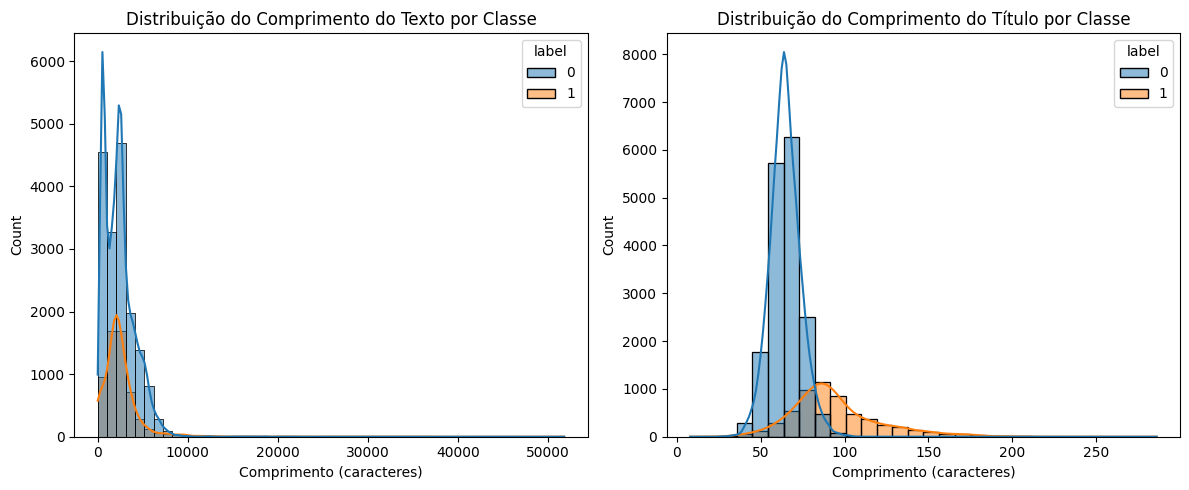

In [9]:
# Análise de comprimento dos textos
train['text_length'] = train['text'].str.len()
train['title_length'] = train['title'].str.len()

print("\n=== Estatísticas de comprimento dos textos ===")
print("Texto - min:", train['text_length'].min(), "max:", train['text_length'].max(), "média:", train['text_length'].mean())
print("Título - min:", train['title_length'].min(), "max:", train['title_length'].max(), "média:", train['title_length'].mean())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data=train, x='text_length', hue='label', bins=50, kde=True)
plt.title('Distribuição do Comprimento do Texto por Classe')
plt.xlabel('Comprimento (caracteres)')
plt.subplot(1,2,2)
sns.histplot(data=train, x='title_length', hue='label', bins=30, kde=True)
plt.title('Distribuição do Comprimento do Título por Classe')
plt.xlabel('Comprimento (caracteres)')
plt.tight_layout()
plt.show()


=== Viés da palavra 'Reuters' ===
label               0         1
has_reuters                    
False        0.005135  0.994865
True         0.994650  0.005350


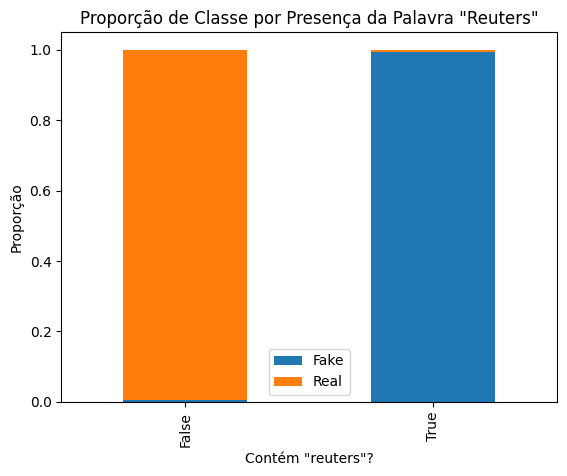

In [11]:
# Análise do viés "Reuters"
train["has_reuters"] = train["text"].str.contains("reuters", case=False)
crosstab = pd.crosstab(train["has_reuters"], train["label"], normalize='index')
print("\n=== Viés da palavra 'Reuters' ===")
print(crosstab)

crosstab.plot(kind='bar', stacked=True)
plt.title('Proporção de Classe por Presença da Palavra "Reuters"')
plt.xlabel('Contém "reuters"?')
plt.ylabel('Proporção')
plt.legend(['Fake', 'Real'])
plt.show()


A palavra "Reuters" apresenta um viés extremo: 99,5% das notícias que a contêm são reais (label 0), enquanto 99,5% das que não a contêm são falsas (label 1).

Isso significa que o modelo poderia "colar" nessa heurística em vez de aprender padrões semânticos de desinformação.

Esse viés precisa ser tratado monitorado via explicabilidade para garantir que o modelo não dependa exclusivamente dele.



In [12]:
# Análise de palavras mais frequentes
from sklearn.feature_extraction.text import CountVectorizer

fake_texts = train[train['label']==0]['text'].dropna()
real_texts = train[train['label']==1]['text'].dropna()

vectorizer = CountVectorizer(stop_words='english', max_features=20)

# Para notícias falsas
fake_vec = vectorizer.fit_transform(fake_texts)
fake_words = pd.DataFrame(fake_vec.sum(axis=0).T, index=vectorizer.get_feature_names_out(), columns=['count']).sort_values('count', ascending=False)
print("\n=== 20 palavras mais frequentes em notícias FALSAS ===")
print(fake_words.head(20))

# Para notícias reais
real_vec = vectorizer.fit_transform(real_texts)
real_words = pd.DataFrame(real_vec.sum(axis=0).T, index=vectorizer.get_feature_names_out(), columns=['count']).sort_values('count', ascending=False)
print("\n=== 20 palavras mais frequentes em notícias REAIS ===")
print(real_words.head(20))


=== 20 palavras mais frequentes em notícias FALSAS ===
            count
said        79562
trump       43710
reuters     23197
president   22591
state       16920
government  15217
new         13496
states      13423
house       13224
republican  13194
united      12528
people      12318
year        11915
told        11476
washington  10425
party       10240
election     9899
campaign     8633
donald       8391
security     8190

=== 20 palavras mais frequentes em notícias REAIS ===
           count
trump      19380
said        8168
president   6823
people      6315
just        4966
clinton     4744
donald      4476
like        4421
obama       4343
new         3524
news        3491
hillary     3483
time        3406
state       3303
white       3223
american    2924
media       2846
america     2792
twitter     2739
right       2714



=== Distribuição de subject por classe ===
label              0    1
subject                  
Government News  0.0  1.0
Middle-east      0.0  1.0
News             0.0  1.0
US_News          0.0  1.0
left-news        0.0  1.0
politics         0.0  1.0
politicsNews     1.0  0.0
worldnews        1.0  0.0


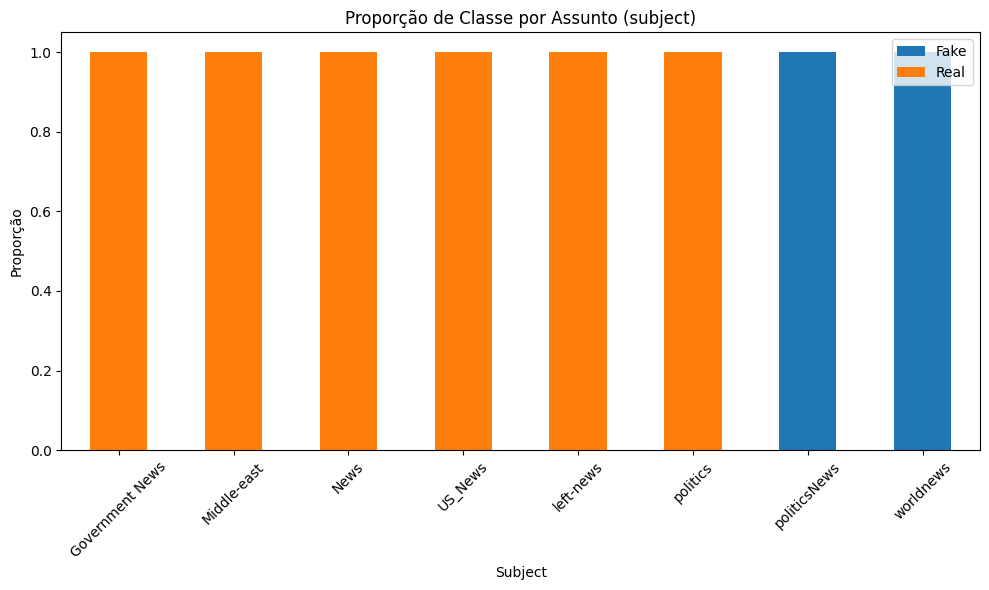

In [13]:
# Análise de subject
if 'subject' in train.columns:
    print("\n=== Distribuição de subject por classe ===")
    subject_dist = pd.crosstab(train['subject'], train['label'], normalize='index')
    print(subject_dist)
    subject_dist.plot(kind='bar', stacked=True, figsize=(10,6))
    plt.title('Proporção de Classe por Assunto (subject)')
    plt.xlabel('Subject')
    plt.ylabel('Proporção')
    plt.legend(['Fake', 'Real'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

A coluna subject apresenta separação perfeita entre as classes:

politicsNews e worldnews são 100% reais (label 0).

Todas as outras categorias (Government News, Middle-east, News, US_News, left-news, politics) são 100% falsas (label 1).

Isso constitui um vazamento de dados (data leakage): o modelo poderia classificar corretamente apenas olhando o assunto, sem aprender padrões textuais.

